<a href="https://colab.research.google.com/github/aashyy21/Advanced-data-structure-lab/blob/main/Apple_Stock_Analysis_2024_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Download stock data (no API key needed)
!pip install yfinance -q
import yfinance as yf

In [ ]:

# Download 1 year of Apple stock data
df = yf.download('AAPL', start='2024-01-01', end='2025-01-01')
df.reset_index(inplace=True)
print(df.head())
print(df.shape)

/tmp/ipykernel_2162/2468767039.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2024-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

Price        Date       Close        High         Low        Open    Volume
Ticker                   AAPL        AAPL        AAPL        AAPL      AAPL
0      2024-01-02  183.562195  186.330858  181.831782  185.055288  82488700
1      2024-01-03  182.187744  183.799505  181.376915  182.158081  58414500
2      2024-01-04  179.873932  181.040717  178.855462  180.111236  71983600
3      2024-01-05  179.152100  180.714417  178.153410  179.953046  62379700
4      2024-01-08  183.483093  183.522654  179.468538  180.051930  59144500
(252, 6)


In [ ]:

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check outliers in Volume
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
df = df[df['Volume'] < (Q3 + 1.5 * IQR)]

print("Cleaned shape:", df.shape)

Missing values:
 Price   Ticker
Date              0
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64
Cleaned shape: (252, 6)


In [ ]:
# Add useful columns
df['Daily Return'] = df['Close'].pct_change() * 100
df['MA_20'] = df['Close'].rolling(20).mean()  # 20-day average
df['MA_50'] = df['Close'].rolling(50).mean()  # 50-day average

print(df[['Date','Close','Daily Return','MA_20']].tail(10))

Price  Date       Close Daily Return       MA_20
Ticker             AAPL                         
242     NaT  251.870773     0.971953  238.904125
243     NaT  246.475266    -2.142173  239.886350
244     NaT  248.204208     0.701467  240.919251
245     NaT         NaN     0.000000         NaN
246     NaT  253.649429     2.193847         NaN
247     NaT  256.560822     1.147802         NaN
248     NaT  257.375580     0.317569         NaN
249     NaT  253.967392    -1.324208         NaN
250     NaT  250.598907    -1.326345         NaN
251     NaT  248.830200    -0.705792         NaN


/tmp/ipykernel_2162/2446924973.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Daily Return'] = df['Close'].pct_change() * 100


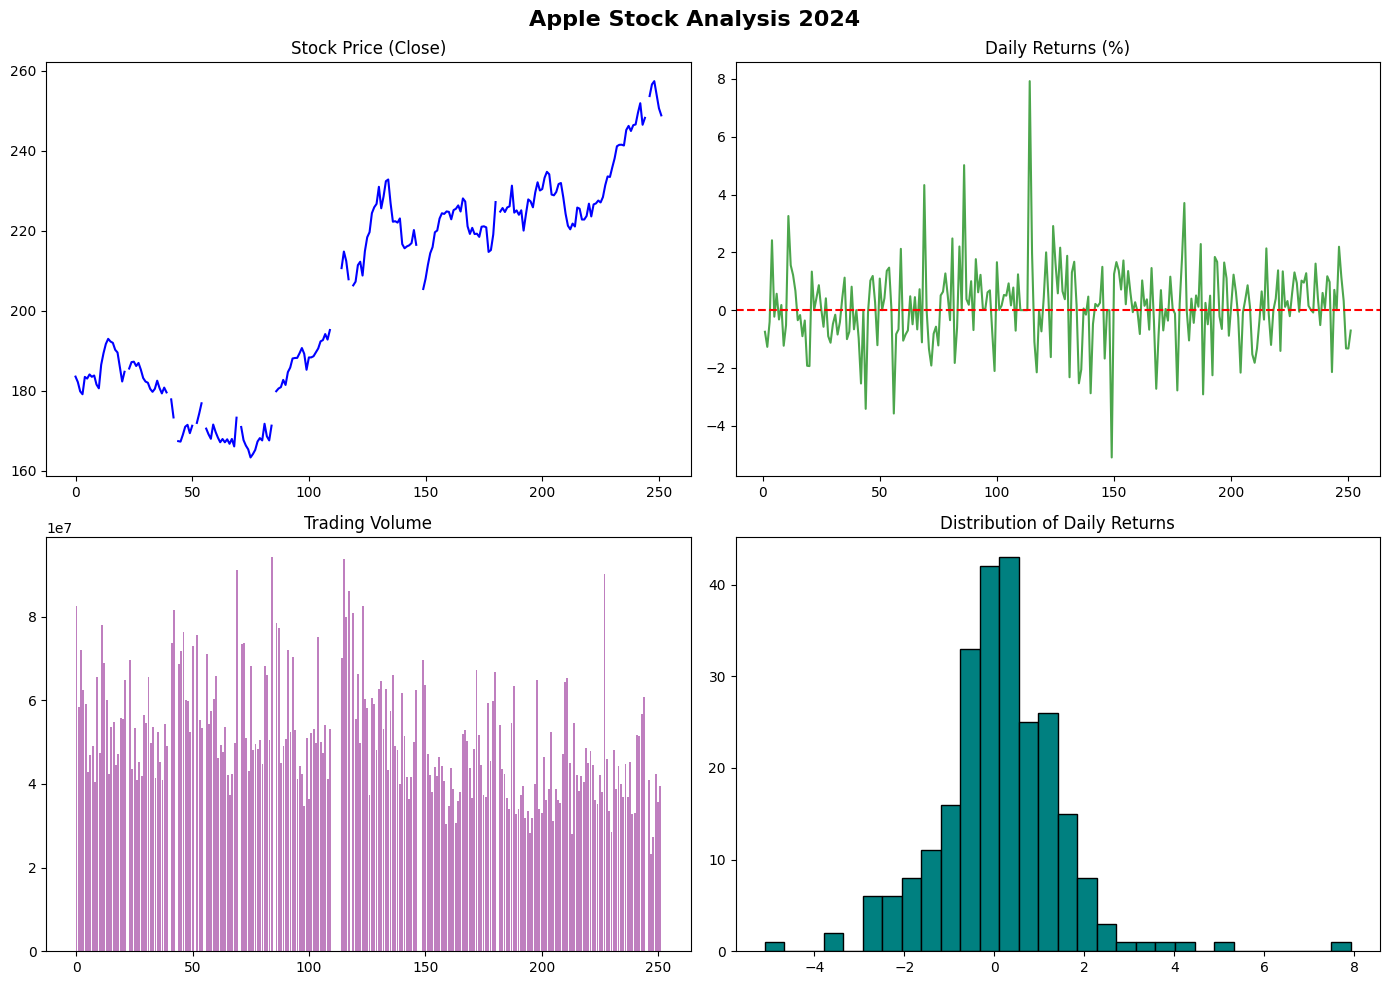

Done!


In [11]:

# Reset and plot cleanly
close = df['Close'].values.flatten()
dates = range(len(close))
returns = df['Daily Return'].values.flatten()
volume = df['Volume'].values.flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Apple Stock Analysis 2024', fontsize=16, fontweight='bold')

axes[0,0].plot(dates, close, color='blue')
axes[0,0].set_title('Stock Price (Close)')

axes[0,1].plot(dates, returns, color='green', alpha=0.7)
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_title('Daily Returns (%)')

axes[1,0].bar(dates, volume, color='purple', alpha=0.5)
axes[1,0].set_title('Trading Volume')

axes[1,1].hist(returns[~np.isnan(returns)], bins=30, color='teal', edgecolor='black')
axes[1,1].set_title('Distribution of Daily Returns')

plt.tight_layout()
plt.savefig('stock_dashboard.png', dpi=150)
plt.show()
print("Done!")

In [ ]:

start = float(df['Close'].iloc[0])
end = float(df['Close'].iloc[-1])
change = ((end - start) / start) * 100
avg = float(df['Daily Return'].mean())
gain = float(df['Daily Return'].max())
loss = float(df['Daily Return'].min())

print("=== STOCK ANALYSIS SUMMARY ===")
print("Starting Price: $", round(start, 2))
print("Ending Price: $", round(end, 2))
print("Total Return: ", round(change, 2), "%")
print("Avg Daily Return: ", round(avg, 2), "%")
print("Max Gain in a Day: ", round(gain, 2), "%")
print("Max Loss in a Day: ", round(loss, 2), "%")

=== STOCK ANALYSIS SUMMARY ===
Starting Price: $ 183.56
Ending Price: $ 248.83
Total Return:  35.56 %
Avg Daily Return:  0.13 %
Max Gain in a Day:  7.92 %
Max Loss in a Day:  -5.1 %


/tmp/ipykernel_2162/833805007.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  start = float(df['Close'].iloc[0])
/tmp/ipykernel_2162/833805007.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  end = float(df['Close'].iloc[-1])
